# Align2DBulk — simple demo
Align a stack of 50 HAADF-STEM frames with known sub-pixel shifts using GPU-accelerated phase correlation.

In [19]:
try:
    %load_ext autoreload
    %autoreload 2
    %env ANYWIDGET_HMR=1
except Exception:
    pass  # autoreload unavailable (Colab Python 3.12+)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: ANYWIDGET_HMR=1


In [20]:
import numpy as np
import torch
import quantem.widget
from quantem.widget import Align2DBulk, Show2D, Show3D, profile

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(42)
print(f"Device: {device}")
print(f"quantem.widget {quantem.widget.__version__}")
profile()

Device: mps
quantem.widget 0.0.12


## Generate synthetic STEM frames
Create a perovskite crystal reference and 49 shifted copies with independent scan noise.

In [21]:
N = 256
rows = torch.arange(N, device=device, dtype=torch.float32)
yy, xx = torch.meshgrid(rows, rows, indexing="ij")
img = torch.zeros((N, N), device=device, dtype=torch.float32)
a = 16
sig_a, sig_b = 2.2, 1.8
ni = N // a + 3
ai_idx = torch.arange(-1, ni, device=device, dtype=torch.float32)
a_cx = (ai_idx * a).unsqueeze(1)
a_cy = (ai_idx * a).unsqueeze(0)
a_cx_flat = a_cx.expand(ni + 1, ni + 1).reshape(-1, 1, 1)
a_cy_flat = a_cy.expand(ni + 1, ni + 1).reshape(-1, 1, 1)
img += (torch.exp(-((xx.unsqueeze(0) - a_cx_flat)**2 + (yy.unsqueeze(0) - a_cy_flat)**2) / (2 * sig_a**2))).sum(0)
b_cx = (ai_idx * a + a / 2).unsqueeze(1)
b_cy = (ai_idx * a + a / 2).unsqueeze(0)
b_cx_flat = b_cx.expand(ni + 1, ni + 1).reshape(-1, 1, 1)
b_cy_flat = b_cy.expand(ni + 1, ni + 1).reshape(-1, 1, 1)
img += 0.55 * (torch.exp(-((xx.unsqueeze(0) - b_cx_flat)**2 + (yy.unsqueeze(0) - b_cy_flat)**2) / (2 * sig_b**2))).sum(0)
ref = img.cpu().numpy().astype(np.float32)
# Create 50 frames with known sub-pixel shifts + independent noise
n_frames = 50
true_shifts = [(0.0, 0.0)] + [(rng.uniform(-8, 8), rng.uniform(-8, 8)) for _ in range(n_frames - 1)]
def fourier_shift(img, dy, dx):
    h, w = img.shape
    fy = np.fft.fftfreq(h).reshape(-1, 1)
    fx = np.fft.fftfreq(w).reshape(1, -1)
    phase = np.exp(-2j * np.pi * (fy * dy + fx * dx))
    return np.real(np.fft.ifft2(np.fft.fft2(img) * phase)).astype(np.float32)
frames = []
for dy, dx in true_shifts:
    frame = fourier_shift(ref, dy, dx)
    frame += rng.normal(0, 0.03, (N, N)).astype(np.float32)
    frames.append(frame)
stack = np.stack(frames, axis=0)
print(f"Stack: {stack.shape}")
print(f"First 10 true shifts (dy, dx):")
for i, (dy, dx) in enumerate(true_shifts[:10]):
    print(f"  [{i}] dy={dy:+6.2f}  dx={dx:+6.2f}")
print(f"  ... ({n_frames - 10} more frames)")

Stack: (50, 256, 256)
First 10 true shifts (dy, dx):
  [0] dy= +0.00  dx= +0.00
  [1] dy= +4.38  dx= -0.98
  [2] dy= +5.74  dx= +3.16
  [3] dy= -6.49  dx= +7.61
  [4] dy= +4.18  dx= +4.58
  [5] dy= -5.95  dx= -0.79
  [6] dy= -2.07  dx= +6.83
  [7] dy= +2.30  dx= +5.16
  [8] dy= -0.91  dx= -4.36
  [9] dy= +0.87  dx= -6.98
  ... (40 more frames)


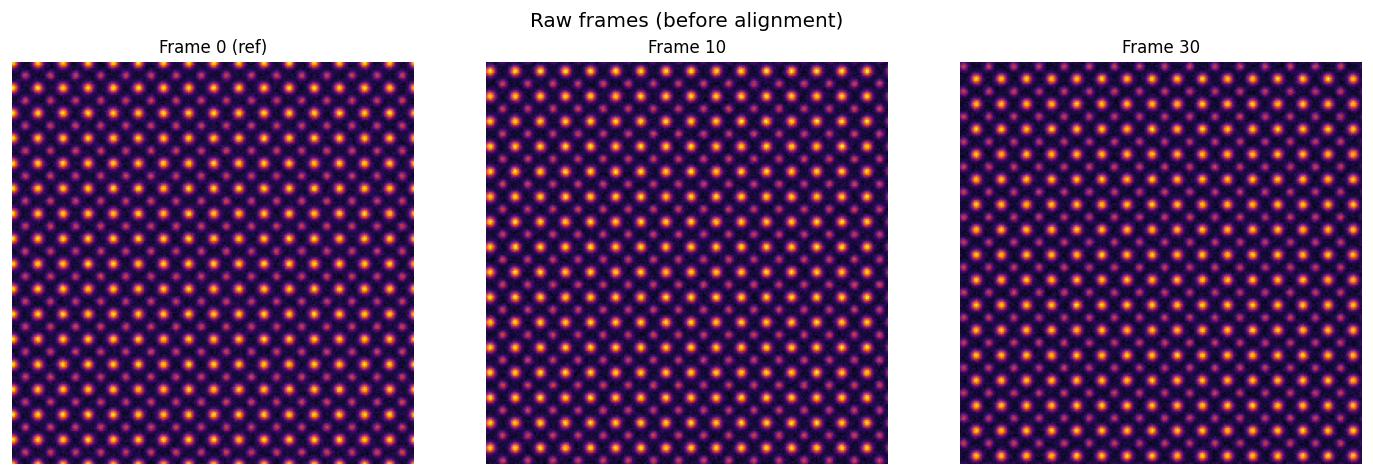

In [22]:
Show2D([stack[0], stack[10], stack[30]], labels=["Frame 0 (ref)", "Frame 10", "Frame 30"], title="Raw frames (before alignment)")

## Align with Align2DBulk
GPU-accelerated alignment — all frames are registered to frame 0 via FFT phase correlation with DFT sub-pixel refinement.

In [23]:
bulk = Align2DBulk(stack, reference=0, max_shift=15, title="Perovskite alignment")
bulk

Align2DBulk(50 frames, 238×239, ref=0)

In [24]:
bulk.summary()

Perovskite alignment
════════════════════════════════════════
Frames:   50  (238×239)
Ref:      frame 0
Crop:     y=[9:247], x=[9:248]
  [0] dx=  +0.00  dy=  +0.00  NCC=1.0000 (ref)
  [1] dx=  +0.97  dy=  -4.38  NCC=0.9847
  [2] dx=  -3.26  dy=  -5.73  NCC=0.9854
  [3] dx=  -7.59  dy=  +6.48  NCC=0.9868
  [4] dx=  -4.57  dy=  -4.17  NCC=0.9859
  [5] dx=  +0.79  dy=  +5.94  NCC=0.9842
  [6] dx=  -6.75  dy=  +2.06  NCC=0.9836
  [7] dx=  -5.16  dy=  -2.30  NCC=0.9852
  [8] dx=  +4.35  dy=  +1.25  NCC=0.9763
  [9] dx=  +6.97  dy=  -0.87  NCC=0.9831
  [10] dx=  -2.10  dy=  -5.23  NCC=0.9843
  [11] dx=  +2.32  dy=  -4.12  NCC=0.9850
  [12] dx=  -6.28  dy=  +8.45  NCC=0.9861
  [13] dx=  +4.74  dy=  -4.44  NCC=0.9844
  [14] dx=  +7.28  dy=  +0.53  NCC=0.9864
  [15] dx=  -2.93  dy=  +5.52  NCC=0.9854
  [16] dx=  -7.47  dy=  -3.91  NCC=0.9855
  [17] dx=  +2.07  dy=  +2.74  NCC=0.9843
  [18] dx=  +4.96  dy=  +0.48  NCC=0.9853
  [19] dx=  +0.38  dy=  +5.91  NCC=0.9854
  [20] dx=  -2.71  dy=  +4.36

## Compare recovered vs true shifts

In [25]:
print(f"{'Frame':>5}  {'True dx':>8}  {'Rec dx':>8}  {'True dy':>8}  {'Rec dy':>8}  {'NCC':>6}")
print("─" * 55)
for i, ((true_dy, true_dx), (rec_dx, rec_dy), ncc) in enumerate(zip(true_shifts, bulk.offsets, bulk.ncc)):
    print(f"{i:>5}  {true_dx:>+8.2f}  {rec_dx:>+8.2f}  {true_dy:>+8.2f}  {rec_dy:>+8.2f}  {ncc:>6.4f}")
# Summary stats
dx_errors = [abs(true_dx - rec_dx) for (true_dy, true_dx), (rec_dx, rec_dy) in zip(true_shifts[1:], bulk.offsets[1:])]
dy_errors = [abs(true_dy - (-rec_dy)) for (true_dy, true_dx), (rec_dx, rec_dy) in zip(true_shifts[1:], bulk.offsets[1:])]
print(f"\nMean dx error: {np.mean(dx_errors):.3f} px")
print(f"Mean dy error: {np.mean(dy_errors):.3f} px")
print(f"Mean NCC: {np.mean(bulk.ncc):.4f}")

Frame   True dx    Rec dx   True dy    Rec dy     NCC
───────────────────────────────────────────────────────
    0     +0.00     +0.00     +0.00     +0.00  1.0000
    1     -0.98     +0.97     +4.38     -4.38  0.9847
    2     +3.16     -3.26     +5.74     -5.73  0.9854
    3     +7.61     -7.59     -6.49     +6.48  0.9868
    4     +4.58     -4.57     +4.18     -4.17  0.9859
    5     -0.79     +0.79     -5.95     +5.94  0.9842
    6     +6.83     -6.75     -2.07     +2.06  0.9836
    7     +5.16     -5.16     +2.30     -2.30  0.9852
    8     -4.36     +4.35     -0.91     +1.25  0.9763
    9     -6.98     +6.97     +0.87     -0.87  0.9831
   10     +2.11     -2.10     +5.24     -5.23  0.9843
   11     -2.33     +2.32     +4.13     -4.12  0.9850
   12     +6.29     -6.28     +7.53     +8.45  0.9861
   13     -4.89     +4.74     +4.45     -4.44  0.9844
   14     -7.30     +7.28     -0.53     +0.53  0.9864
   15     +2.93     -2.93     -5.53     +5.52  0.9854
   16     +7.48     -7.47 

## View aligned stack

In [26]:
Show3D(bulk.stack, title="Aligned stack")

Show3D(50×238×239, frame=25, cmap=magma)

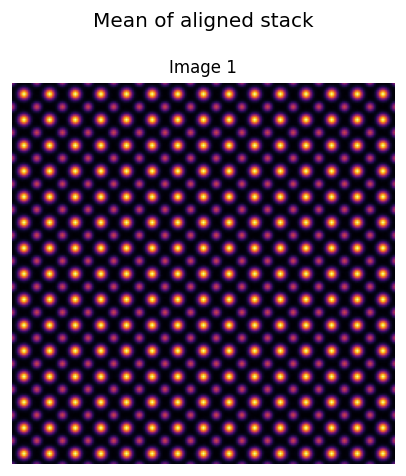

In [27]:
Show2D(bulk.stack.mean(axis=0), title="Mean of aligned stack")